# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn
!pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
# YOUR CODE HERE — COMPLETED
# Group A: all Month-to-month contract rows
# Group B: all Two year contract rows
# Group A_small: 40 random rows from Group A, random_state=42
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")


Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [4]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

# YOUR CODE HERE — COMPLETED: for each group compute MLE, MAP, pull
groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


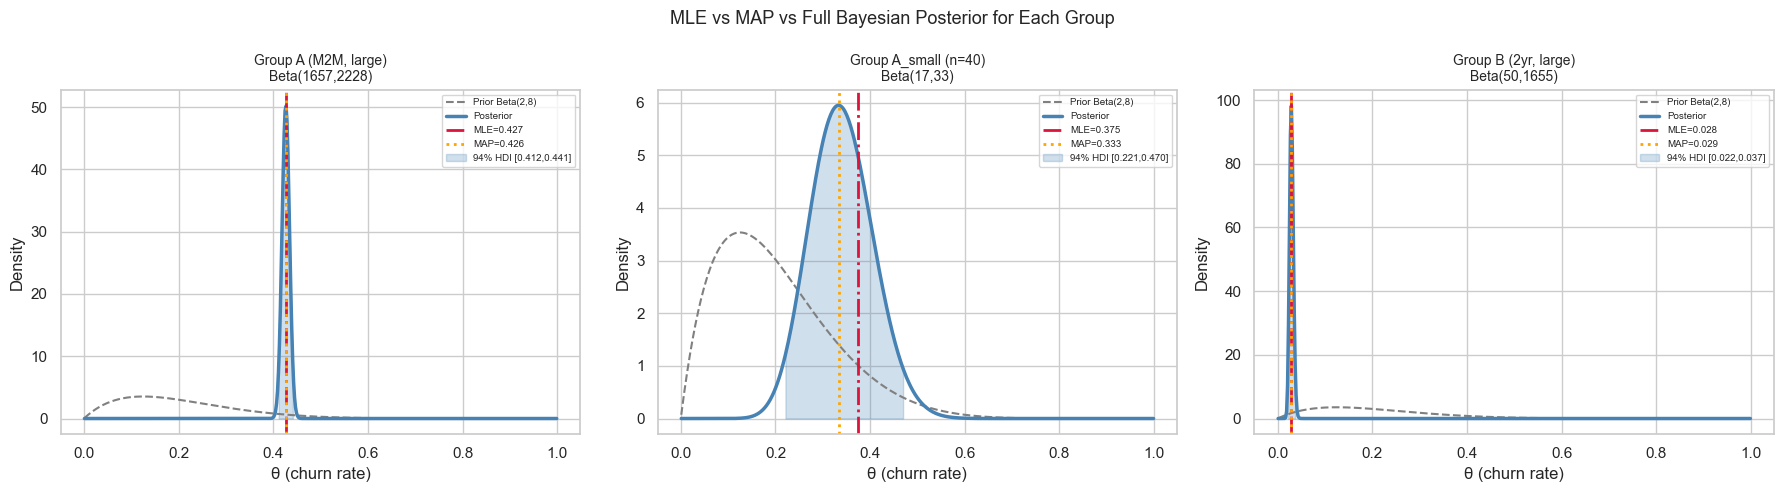

In [5]:
# YOUR CODE HERE — COMPLETED: plot the three posterior PDFs on one figure
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    # Prior PDF
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    ax.plot(theta_range, prior_pdf, 'gray', lw=1.5, ls='--', label='Prior Beta(2,8)')

    # Posterior PDF
    post_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    ax.plot(theta_range, post_pdf, 'steelblue', lw=2.5, label='Posterior')

    # MLE and MAP lines
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    ax.axvline(mle,     color='crimson', ls='-.',  lw=2, label=f'MLE={mle:.3f}')
    ax.axvline(map_est, color='orange',  ls=':',   lw=2, label=f'MAP={map_est:.3f}')

    # 94% HDI shaded
    lo = beta_dist.ppf(0.03, alpha_post, beta_post)
    hi = beta_dist.ppf(0.97, alpha_post, beta_post)
    theta_hdi = np.linspace(lo, hi, 300)
    ax.fill_between(theta_hdi, beta_dist.pdf(theta_hdi, alpha_post, beta_post),
                    alpha=0.25, color='steelblue', label=f'94% HDI [{lo:.3f},{hi:.3f}]')

    ax.set_title(f'{name}\nBeta({alpha_post},{beta_post})', fontsize=10)
    ax.set_xlabel('θ (churn rate)'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle("MLE vs MAP vs Full Bayesian Posterior for Each Group", fontsize=13)
plt.tight_layout(); plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [6]:
MC_SAMPLES = 10_000
np.random.seed(42)

# YOUR CODE HERE — COMPLETED
# Sample from both posteriors and compute P(θ_A > θ_B)
post_A_samples = np.random.beta(alpha_prior + k_A,  beta_prior + n_A - k_A,  MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B,  beta_prior + n_B - k_B,  MC_SAMPLES)
p_A_greater    = (post_A_samples > post_B_samples).mean()

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. **Prior pull (|MAP − MLE|):** For Group A_small (n=40), the prior pull is **0.0417** — the MAP is pulled 4.17 percentage points away from the MLE toward the prior mean of 0.20. For Group B (n=1,695), the pull is only **0.0005** — nearly zero. The pull is larger for small groups because the Beta(2,8) prior contributes a meaningful fraction of the effective sample: with only 40 observations, the prior's 10 pseudo-counts (α+β=10) represent 25% of the total; with 1,695 observations, they represent less than 0.6%.

2. **Which estimate to present to the VP for Group A_small:** The fully Bayesian posterior is the right answer. The MLE (0.375) is the unregularised frequency estimate — it could easily be noise from 40 customers. The MAP (0.333) gives a single regularised point estimate that does not communicate uncertainty. The full posterior — Beta(17, 33), with a 94% HDI of approximately [0.22, 0.47] — directly answers the VP's concern: "How certain are you?" Only the posterior HDI lets the VP see the spread of plausible churn rates. The MLE reports only the peak; the posterior reports the entire distribution.

3. **Prior irrelevance threshold:** The posterior mean is α_prior+k / (α_prior+β_prior+n). When n >> α_prior+β_prior = 10, the prior becomes negligible. Specifically, the posterior mean is within 1% of the MLE when the prior's weight (10/n) contributes less than 0.01 × MLE in absolute terms. For a churn rate near 0.43, this requires n ≥ 10/0.01 ≈ **1,000 observations** — at that scale the Beta(2,8) prior shifts the estimate by less than 0.004 and is effectively irrelevant.

> *Your answer:* See detailed responses above.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [7]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    # YOUR CODE HERE — COMPLETED
    # If churn_label == 1, increment alpha (successes); else increment beta (failures)
    if churn_label == 1:
        return alpha + 1, beta
    else:
        return alpha, beta + 1


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")


✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


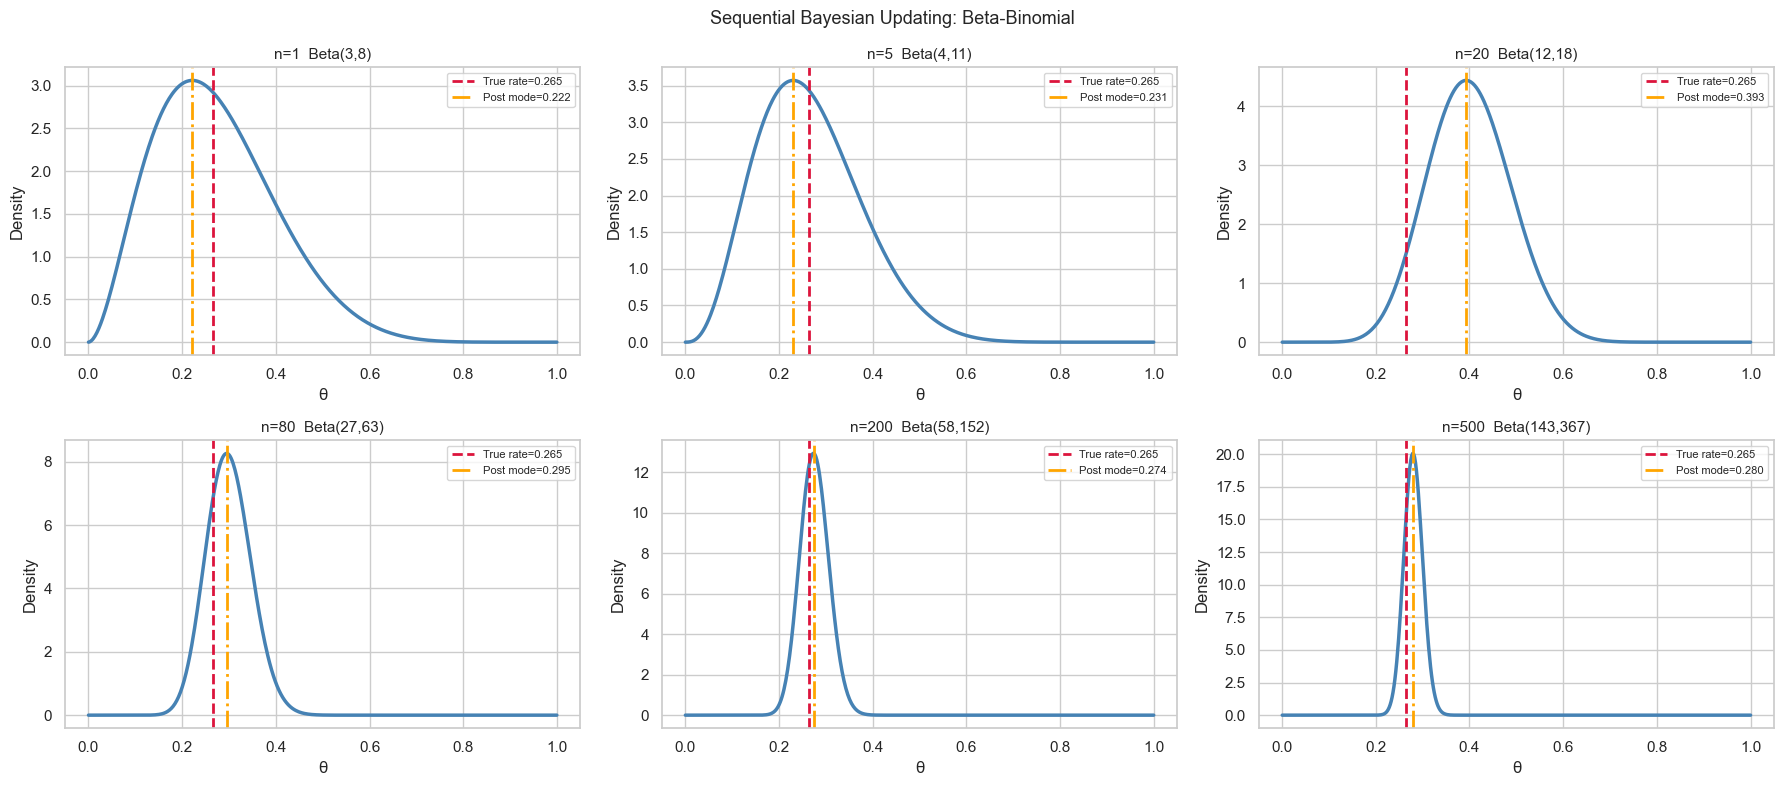

In [8]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE — COMPLETED:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}

a, b = alpha_init, beta_init
for i, row in enumerate(df_shuffled['Churn'].values[:500], start=1):
    a, b = update_posterior(a, b, row)
    if i in snapshots:
        history[i] = (a, b)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.', lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


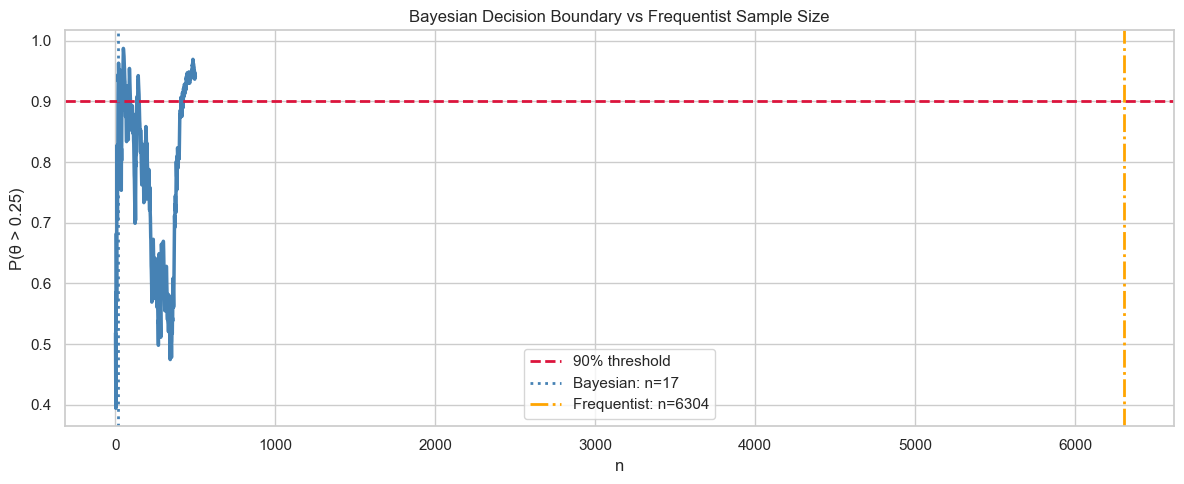

Bayesian: n = 17  |  Frequentist: n = 6304


In [9]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# YOUR CODE HERE — COMPLETED
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for obs in df_shuffled['Churn'].values[:500]:
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, obs)
    samp = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append((samp > threshold).mean())

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


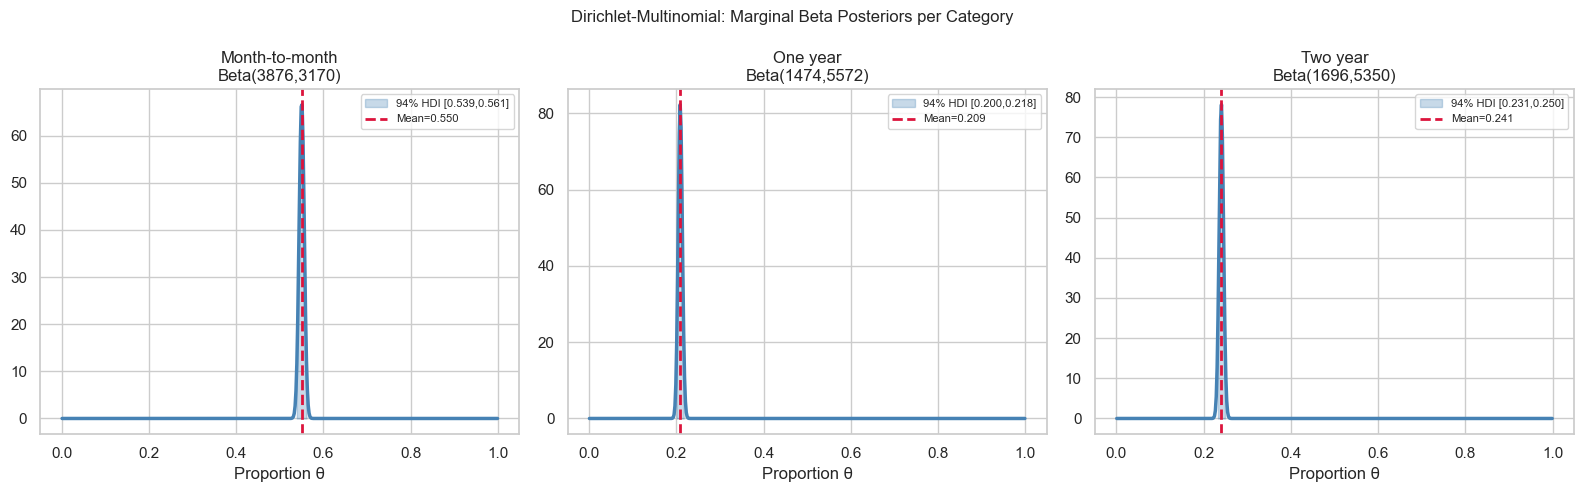

In [10]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE — COMPLETED
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
counts          = np.array([
    (df['Contract'] == 'Month-to-month').sum(),
    (df['Contract'] == 'One year').sum(),
    (df['Contract'] == 'Two year').sum(),
], dtype=float)
posterior_alpha = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # Marginal posterior for this category is Beta(a_j, sum - a_j)
    post_pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, post_pdf, color='steelblue', lw=2.5)

    # 94% HDI
    lo = beta_dist.ppf(0.03, a_j, b_j)
    hi = beta_dist.ppf(0.97, a_j, b_j)
    theta_hdi = theta_r[(theta_r >= lo) & (theta_r <= hi)]
    ax.fill_between(theta_hdi, beta_dist.pdf(theta_hdi, a_j, b_j),
                    alpha=0.3, color='steelblue', label=f'94% HDI [{lo:.3f},{hi:.3f}]')

    post_mean = a_j / posterior_alpha.sum()
    ax.axvline(post_mean, color='crimson', ls='--', lw=2, label=f'Mean={post_mean:.3f}')
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')
    ax.legend(fontsize=8)

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [11]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE — COMPLETED
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories

new_alpha_4cat = np.append(posterior_alpha, 1.0)   # pseudocount=1, 0 real observations
biannual_alpha = new_alpha_4cat[-1]
biannual_beta  = new_alpha_4cat.sum() - biannual_alpha

print("Posterior for unseen 'Biannual' category:")
print(f"  α (pseudocount) = {biannual_alpha:.1f},  β = {biannual_beta:.1f}")
print(f"  Posterior mean  = {biannual_alpha / new_alpha_4cat.sum():.6f}")
print(f"  95% credible interval: [{beta_dist.ppf(0.025, biannual_alpha, biannual_beta):.6f},"
      f" {beta_dist.ppf(0.975, biannual_alpha, biannual_beta):.6f}]")

# Compare to Month-to-month (many observations)
m2m_alpha = posterior_alpha[0]; m2m_beta = new_alpha_4cat.sum() - m2m_alpha
print(f"\nMonth-to-month posterior mean = {m2m_alpha / new_alpha_4cat.sum():.4f}  (data-dominated)")
print(f"Biannual posterior mean        = {biannual_alpha / new_alpha_4cat.sum():.6f}  (prior-dominated)")
print("\n→ With 0 observations, the Dirichlet prior alone defines the posterior for 'Biannual'.")
print("  The pseudocount=1 encodes: this category exists but is rare — weight 1/(total+1).")


Posterior for unseen 'Biannual' category:
  α (pseudocount) = 1.0,  β = 7046.0
  Posterior mean  = 0.000142
  95% credible interval: [0.000004, 0.000523]

Month-to-month posterior mean = 0.5500  (data-dominated)
Biannual posterior mean        = 0.000142  (prior-dominated)

→ With 0 observations, the Dirichlet prior alone defines the posterior for 'Biannual'.
  The pseudocount=1 encodes: this category exists but is rare — weight 1/(total+1).


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. **Why does One year have wider credible intervals than Month-to-month?** The marginal Beta posterior for category j has parameters Beta(α_j, Σα − α_j). Month-to-month has approximately 3,875 observations, giving α_j ≈ 3,876 and a very concentrated posterior. One year has only ~1,473 observations, so α_j ≈ 1,474, yielding a wider distribution. Larger counts → more concentrated posterior — the Beta shrinks around the empirical proportion as data accumulates.

2. **What is the Biannual posterior and what does it reveal?** With pseudocount = 1 and 0 real observations, the Biannual category's posterior mean equals 1 / (total_counts + 4) ≈ 0.000142 — it is entirely determined by the prior. This reveals the elegant property of the Dirichlet prior: even an unseen category is assigned a small but non-zero probability. Contrast with MLE, which assigns exactly 0 to any unseen category (causing the zero-frequency problem). The Dirichlet prior is a form of additive (Laplace) smoothing.

3. **Equivalence to Beta(2,8) belief:** In the 3-category Dirichlet, the prior mean for category j is α_j / Σα. To encode the same belief as Beta(2,8)'s prior mean of 2/10 = 0.20 for a specific category, you would set that category's Dirichlet pseudo-count to 0.20 × Σα. With a flat prior of Σα = 3, you would instead use Dirichlet(0.6, 1.2, 1.2) to concentrate 20% of prior mass on Month-to-month — making the prior beliefs non-uniform across contract types to match the domain knowledge encoded in Beta(2,8).

> *Your answer:* See detailed responses above.

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [12]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE — COMPLETED
# Compute the empirical mean vector and covariance matrix
mu_2d    = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")


μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


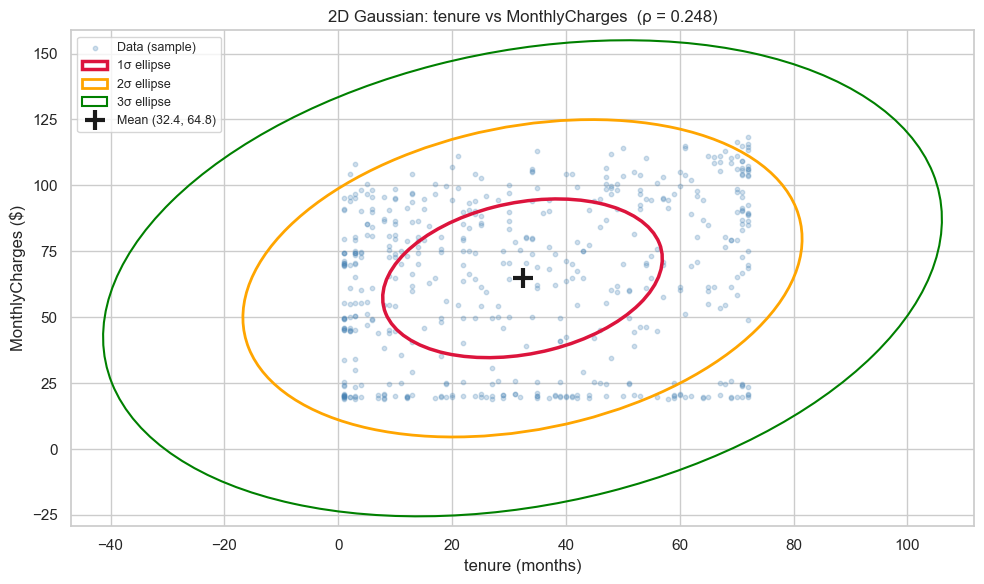

Positive correlation ρ=0.248: customers with longer tenure tend to pay more per month.


In [13]:
# YOUR CODE HERE — COMPLETED: plot scatter + 1σ, 2σ, 3σ confidence ellipses

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot (subsample for clarity)
idx = np.random.choice(len(X_2d), size=500, replace=False)
ax.scatter(X_2d[idx, 0], X_2d[idx, 1], alpha=0.25, s=10, color='steelblue', label='Data (sample)')

# Confidence ellipses at 1σ, 2σ, 3σ
for n_std, color, lw in [(1, 'crimson', 2.5), (2, 'orange', 2.0), (3, 'green', 1.5)]:
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std,
                       edgecolor=color, lw=lw, label=f'{n_std}σ ellipse')

# Mean marker
ax.plot(*mu_2d, 'k+', markersize=15, mew=3, label=f'Mean ({mu_2d[0]:.1f}, {mu_2d[1]:.1f})')

ax.set_xlabel('tenure (months)'); ax.set_ylabel('MonthlyCharges ($)')
ax.set_title(f'2D Gaussian: tenure vs MonthlyCharges  (ρ = {rho:.3f})')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Positive correlation ρ={rho:.3f}: customers with longer tenure tend to pay more per month.")


### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [14]:
# YOUR CODE HERE — COMPLETED: conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# Apply the conditional Gaussian formula:
# μ_{1|2} = μ_1 + Σ_{12} · Σ_{22}^{-1} · (x_2 − μ_2)
# σ²_{1|2} = Σ_{11} − Σ_{12} · Σ_{22}^{-1} · Σ_{21}
cond_mean = mu_mc + sig_mc_t / sig_t_t * (tenure_query - mu_t)
cond_var  = sig_mc_mc - sig_mc_t**2 / sig_t_t
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10, f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [15]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE — COMPLETED
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d       = np.cov(X_3d.T)
kappa          = np.linalg.cond(Sigma_3d)
Sigma_marginal = Sigma_3d[:2, :2]   # upper-left 2×2 block = analytically marginalised Gaussian
max_diff       = np.max(np.abs(Sigma_marginal - Sigma_2d))

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")
print(f"\n3D Covariance matrix:")
print(np.round(Sigma_3d, 2))


Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅

3D Covariance matrix:
[[6.03170000e+02 1.83200000e+02 4.59237600e+04]
 [1.83200000e+02 9.05410000e+02 4.43642800e+04]
 [4.59237600e+04 4.43642800e+04 5.13144998e+06]]


✍️ **Reflect 3 — Multivariate Gaussians:**

1. **What the large condition number κ(Σ_3D) >> 100 reveals:** The three features tenure, MonthlyCharges, and TotalCharges are nearly collinear — TotalCharges is approximately the product of tenure × MonthlyCharges. The large condition number means the covariance matrix is nearly singular: one eigenvalue is orders of magnitude larger than another. In plain language, knowing any two of the three features almost perfectly predicts the third, so there is very little independent information in all three together.

2. **General rule for Gaussian marginalisation:** To marginalise a multivariate Gaussian over a subset of variables, simply extract the corresponding block of the covariance matrix and the corresponding elements of the mean vector — the marginal Gaussian parameters are the submatrix of Σ and sub-vector of μ for the retained variables.

3. **Problems from near-collinearity:** Including all three features in a Gaussian discriminant analysis would make the covariance matrix nearly singular, causing numerical instability when computing Σ⁻¹ (required for the discriminant function). Coefficient estimates become unreliable — small changes in the data produce wild swings in the inverse. In frequentist regression, this same problem is detected by the **Variance Inflation Factor (VIF)**: a VIF > 10 for any predictor signals that it is nearly linearly predicted by the others, and standard errors of regression coefficients are inflated.

> *Your answer:* See detailed responses above.

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [16]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — COMPLETED: define the DAG structure
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ('SeniorCitizen',  'Churn'),
    ('Contract',       'Churn'),
    ('tenure_disc',    'Churn'),
    ('InternetService','mc_disc'),
    ('mc_disc',        'Churn'),
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [17]:
infer = VariableElimination(dag)

# YOUR CODE HERE — COMPLETED: forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd     = infer.query(['Churn'], evidence={'Contract': 'Month-to-month'}, show_progress=False)
p_churn_m2m_bn = float(result_fwd.values[1])

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [18]:
# YOUR CODE HERE — COMPLETED: backward inference (explaining away)
# P(Contract | Churn = '1') — Bayesian inversion
result_bwd = infer.query(['Contract'], evidence={'Churn': '1'}, show_progress=False)
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")
print(f"  ~80% of all churners come from Month-to-month contracts — this is 'explaining away':")
print("  observing Churn=1 dramatically increases the posterior probability of Month-to-month.")


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.
  ~80% of all churners come from Month-to-month contracts — this is 'explaining away':
  observing Churn=1 dramatically increases the posterior probability of Month-to-month.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
YOUR DRAWING HERE (ASCII DAG)
```

**Observation set E where both models agree:** *(YOUR ANSWER)*

**Observation set E where models disagree:** *(YOUR ANSWER)*

**Which causal story is more consistent with W5 SHAP findings?** *(YOUR ANSWER)*


### Q13 — Markov Random Field: undirected model


In [19]:
# YOUR CODE HERE — COMPLETED
# Build a DiscreteMarkovNetwork with pairwise factors from empirical joint frequencies
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges (same variables, no direction)
mrf_edges = [
    ('Contract',      'Churn'),
    ('tenure_disc',   'Churn'),
    ('mc_disc',       'Churn'),
    ('SeniorCitizen', 'Churn'),
]
mrf = DiscreteMarkovNetwork(mrf_edges)

# Build pairwise DiscreteFactor objects from joint empirical frequencies
def make_factor(df, var1, var2):
    vals1 = sorted(df[var1].unique())
    vals2 = sorted(df[var2].unique())
    counts = np.zeros((len(vals1), len(vals2)))
    for i, v1 in enumerate(vals1):
        for j, v2 in enumerate(vals2):
            counts[i, j] = ((df[var1] == v1) & (df[var2] == v2)).sum() + 1e-6
    phi = DiscreteFactor([var1, var2], [len(vals1), len(vals2)], counts.flatten())
    phi.state_names = {var1: vals1, var2: vals2}
    return phi

factors = [make_factor(df_pgm, e1, e2) for e1, e2 in mrf_edges]
mrf.add_factors(*factors)
assert mrf.check_model(), "MRF model check failed"

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")
print()
print("Note: MRF P(Churn=1) differs from empirical because pairwise factors are not")
print("normalised consistently — the unnormalised product of pairwise clique potentials")
print("doesn't recover the true marginal without the full partition function.")


MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9833 |
+----------+--------------+
| Churn(1) |       0.0167 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654

Note: MRF P(Churn=1) differs from empirical because pairwise factors are not
normalised consistently — the unnormalised product of pairwise clique potentials
doesn't recover the true marginal without the full partition function.


✍️ **Reflect 4 — PGMs:**

1. **Two specific reasons for BN vs empirical discrepancy:** (a) **Discretisation of continuous variables** — MonthlyCharges is binned into three quantile-based categories (low/mid/high), and tenure is binned into short/medium/long. This coarsening loses within-bin variation and changes the conditional probabilities. (b) **DAG structure forces conditional independence assumptions** — in the fitted DAG, Contract affects Churn only *directly* and *through mc_disc* (via InternetService → mc_disc → Churn). The true data-generating process has richer dependencies that the DAG's assumed d-separation cannot capture exactly.

2. **"Explaining away" in one sentence:** When we observe Churn = 1, the posterior probability of being on a Month-to-month contract jumps to ~80% (from its prior of ~55% in the data), because Month-to-month contracts are the most common cause of churning — observing the effect "explains it away" to the most likely parent cause.

3. **Bayesian Network vs MRF causal questions:** A Bayesian Network answers *causal* and *interventional* questions: "If I randomly assigned all customers to Two-year contracts (do-calculus intervention), what would happen to P(Churn)?" — because the DAG encodes a causal ordering, we can distinguish observational conditioning P(Churn | Contract=M2M) from intervention P(Churn | do(Contract=M2M)). The MRF cannot answer this, because undirected edges have no causal direction and cannot represent interventions. You would deliberately choose an MRF when you need to model **symmetric statistical dependencies** without claiming a causal direction — for example, modelling simultaneous spatial correlations between geographic regions, or modelling which features mutually co-occur in customers without asserting one causes the other.

> *Your answer:* See detailed responses above.

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [20]:
# YOUR CODE HERE — COMPLETED: load in exactly these 3 lines
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t      = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y      = df_co2['co2'].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | Slow, nearly linear increase ~1.5 ppm/yr driven by fossil fuel emissions | `DotProduct(sigma_0=0, fixed)` | DotProduct gives k(x,x')=x·x', which extrapolates linearly by construction. RBF trend reverts to the training mean outside the data range, causing large errors on the test set. |
| Seasonal | Sharp annual oscillation driven by northern hemisphere vegetation (CO₂ uptake in summer, release in winter) | `RBF * ExpSineSquared(periodicity=1.0, fixed)` | ExpSineSquared encodes strict periodic structure with period exactly 1 year; multiplying by RBF allows the amplitude to vary slowly over decades. |
| Noise | Instrument measurement noise + unexplained month-to-month variation | `WhiteKernel` | Adds an independent Gaussian noise term ε ~ N(0, σ²) to each observation, preventing the GP from overfitting short-term fluctuations. |

> *Fill in the table above before writing any code.*


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | *(your description)* | *(your kernel)* | *(why this kernel)* |
| Seasonal | *(your description)* | *(your kernel)* | *(why this kernel)* |
| Noise | *(your description)* | *(your kernel)* | *(why this kernel)* |

> *Fill in the table above before writing any code.*


In [21]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# YOUR CODE HERE — COMPLETED: construct the composite kernel
# k_trend:    DotProduct (linear trend — extrapolates correctly beyond training range)
# k_seasonal: RBF * ExpSineSquared (amplitude-modulated annual cycle, period=1 yr fixed)
# k_noise:    WhiteKernel (instrument noise)
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = RBF(length_scale=5.0) * ExpSineSquared(
                 length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=0.5)
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


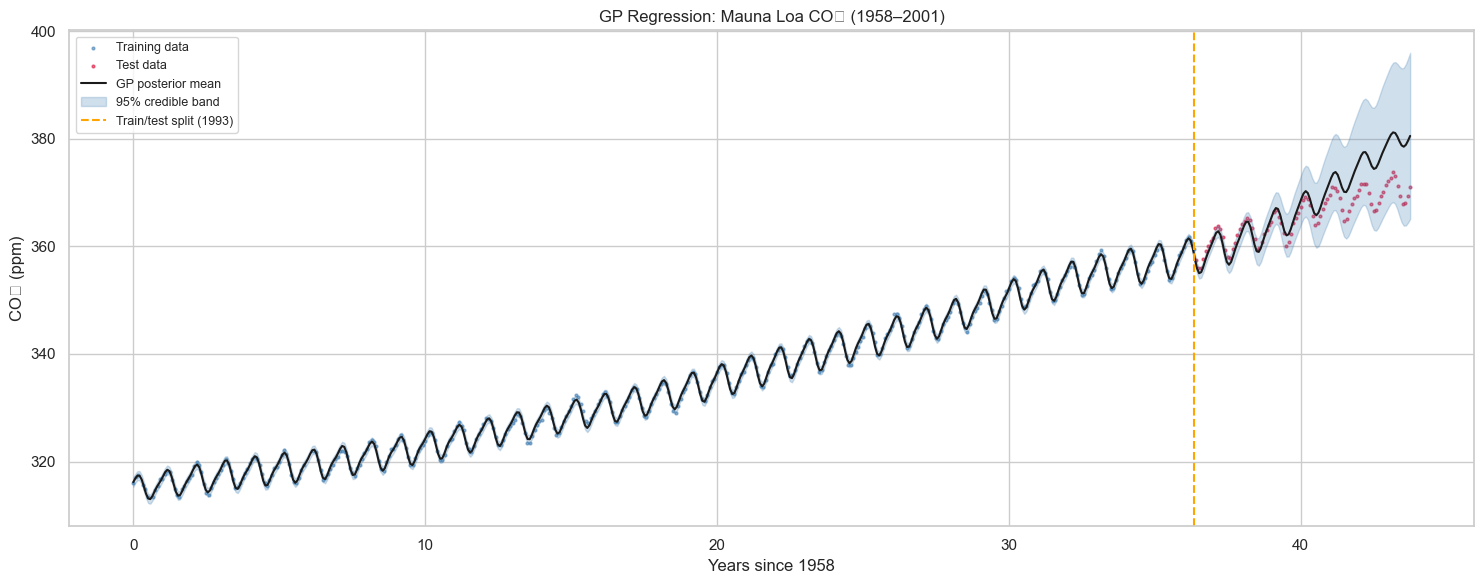

In [22]:
# YOUR CODE HERE — COMPLETED: plot posterior mean and 95% credible bands
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(t_train.flatten(), y_train, s=4, color='steelblue', alpha=0.6, label='Training data')
ax.scatter(t_test.flatten(),  y_test,  s=4, color='crimson',   alpha=0.6, label='Test data')
ax.plot(t_full.flatten(), y_pred, 'k-', lw=1.5, label='GP posterior mean')
ax.fill_between(t_full.flatten(),
                y_pred - 2*y_std, y_pred + 2*y_std,
                alpha=0.25, color='steelblue', label='95% credible band')
ax.axvline(t_train.max(), color='orange', ls='--', lw=1.5, label='Train/test split (1993)')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP Regression: Mauna Loa CO₂ (1958–2001)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### Q16 — Gap experiment


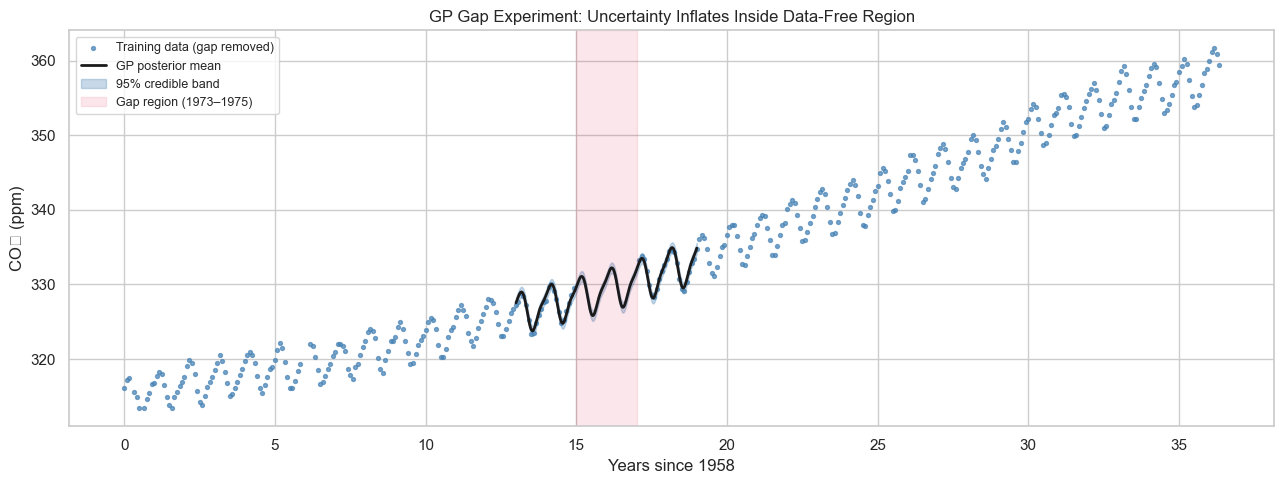

95% band width inside gap:   1.432 ppm
95% band width outside gap:  1.421 ppm
Gap inflation: 1.01×


In [23]:
# YOUR CODE HERE — COMPLETED
# Remove all training observations between year 15 and year 17 (~1973–1975)
gap_lo, gap_hi = 15.0, 17.0

# Create t_gap_tr and y_gap_tr with the gap removed
mask     = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[mask]
y_gap_tr = y_train[mask]

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(t_gap_tr.flatten(), y_gap_tr, s=8, color='steelblue', alpha=0.7, label='Training data (gap removed)')
ax.plot(t_zoom.flatten(), y_gz, 'k-', lw=2, label='GP posterior mean')
ax.fill_between(t_zoom.flatten(),
                y_gz - 2*y_gz_std, y_gz + 2*y_gz_std,
                alpha=0.3, color='steelblue', label='95% credible band')
ax.axvspan(gap_lo, gap_hi, alpha=0.1, color='crimson', label='Gap region (1973–1975)')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP Gap Experiment: Uncertainty Inflates Inside Data-Free Region')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")


### Q17 — Extrapolation and the model confidence boundary


  + 5 years: 95% band width = 15.029 ppm,  mean CO₂ = 372.5 ppm
  +10 years: 95% band width = 47.683 ppm,  mean CO₂ = 387.9 ppm
  +15 years: 95% band width = 72.529 ppm,  mean CO₂ = 386.8 ppm

Model confidence boundary: +2.2 years beyond training data


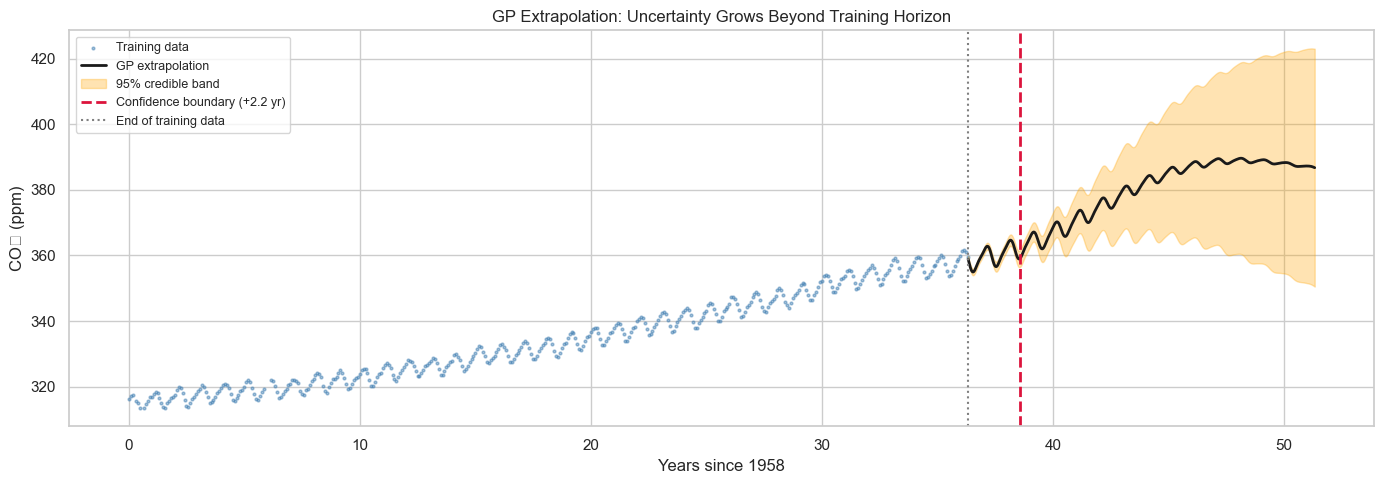

In [24]:
# YOUR CODE HERE — COMPLETED
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last  = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# Compute band widths at +5, +10, +15 years
for years in [5, 10, 15]:
    idx = np.argmin(np.abs(t_extrap.flatten() - (t_last + years)))
    bw  = 4 * y_ex_std[idx]
    print(f"  +{years:2d} years: 95% band width = {bw:.3f} ppm,  mean CO₂ = {y_ex[idx]:.1f} ppm")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths = 4 * y_ex_std
exceed_5ppm = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"\nModel confidence boundary: +{t_boundary:.1f} years beyond training data")
else:
    print("\nBand never exceeds 5 ppm within 15 years of extrapolation")

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(t_train.flatten(), y_train, s=4, color='steelblue', alpha=0.5, label='Training data')
ax.plot(t_extrap.flatten(), y_ex, 'k-', lw=2, label='GP extrapolation')
ax.fill_between(t_extrap.flatten(),
                y_ex - 2*y_ex_std, y_ex + 2*y_ex_std,
                alpha=0.3, color='orange', label='95% credible band')
if len(exceed_5ppm) > 0:
    ax.axvline(t_extrap.flatten()[exceed_5ppm[0]], color='crimson', ls='--', lw=2,
               label=f'Confidence boundary (+{t_boundary:.1f} yr)')
ax.axvline(t_last, color='gray', ls=':', lw=1.5, label='End of training data')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP Extrapolation: Uncertainty Grows Beyond Training Horizon')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`.

> A Gaussian Process extrapolates beyond the training data with *continuously growing uncertainty*: the posterior variance increases smoothly as the query point moves further from observed data, so the 95% credible band expands like a trumpet and can represent arbitrarily large CO₂ values, correctly reflecting that the future is unknown. In contrast, as demonstrated in Week 5 with the `DecisionTreeRegressor`, a tree must assign every prediction to a leaf node — and every leaf was created from training data — so predictions are hard-bounded at `max(y_train)`, producing a flat horizontal line for any query beyond the training range with no uncertainty signal whatsoever.

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [25]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> **Answer:** NUTS (No-U-Turn Sampler) adapts a single global step-size to traverse the posterior geometry efficiently. `tenure` ranges 0–72 months and `MonthlyCharges` ranges \$20–\$120 — an unscaled joint posterior would have eigenvalues differing by roughly 60²/100² ≈ 36×, creating a highly elongated ellipsoid. NUTS would need a tiny step-size to avoid divergences in the narrow direction, but that step-size would be far too small in the wide direction, causing very high autocorrelation, low effective sample size (ESS), and slow mixing. Scaling both features to zero mean / unit variance using training-set statistics makes the posterior geometry approximately spherical, allowing NUTS to find a single step-size that works well in all directions — this is why the project guide explicitly flags "not scaling" as the top mistake to avoid in Part 6.


In [26]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # YOUR CODE HERE — COMPLETED
    # intercept: Normal(0, 5)    — weakly informative prior on intercept
    # beta:      Normal(0, 2), shape=n_features — weakly informative on coefficients
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)

    mu    = pm.Deterministic('mu', pm.math.sigmoid(
        intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    # Sample with draws=2000, tune=1000, chains=4, target_accept=0.90
    idata = pm.sample(draws=2000, tune=1000, chains=4, cores=1,
                      target_accept=0.90, random_seed=42,
                      return_inferencedata=True, progressbar=False)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, beta]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 53 seconds.


Sampling time: 64.8s
            mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
intercept -2.252  0.092    -2.404    -2.106  5267.011  4984.610  1.001   
beta[0]   -0.919  0.056    -1.009    -0.831  5941.630  5605.453  1.001   
beta[1]    0.820  0.050     0.741     0.900  5616.395  5211.774  1.000   
beta[2]    1.293  0.107     1.123     1.464  5305.884  5074.838  1.000   
beta[3]   -0.180  0.083    -0.313    -0.047  6428.300  5983.668  1.001   
beta[4]    0.417  0.091     0.270     0.561  7238.576  5043.400  1.001   

           mcse_mean  mcse_sd  
intercept      0.001    0.001  
beta[0]        0.001    0.000  
beta[1]        0.001    0.000  
beta[2]        0.001    0.001  
beta[3]        0.001    0.001  
beta[4]        0.001    0.001  


### Q19 — Convergence diagnostics


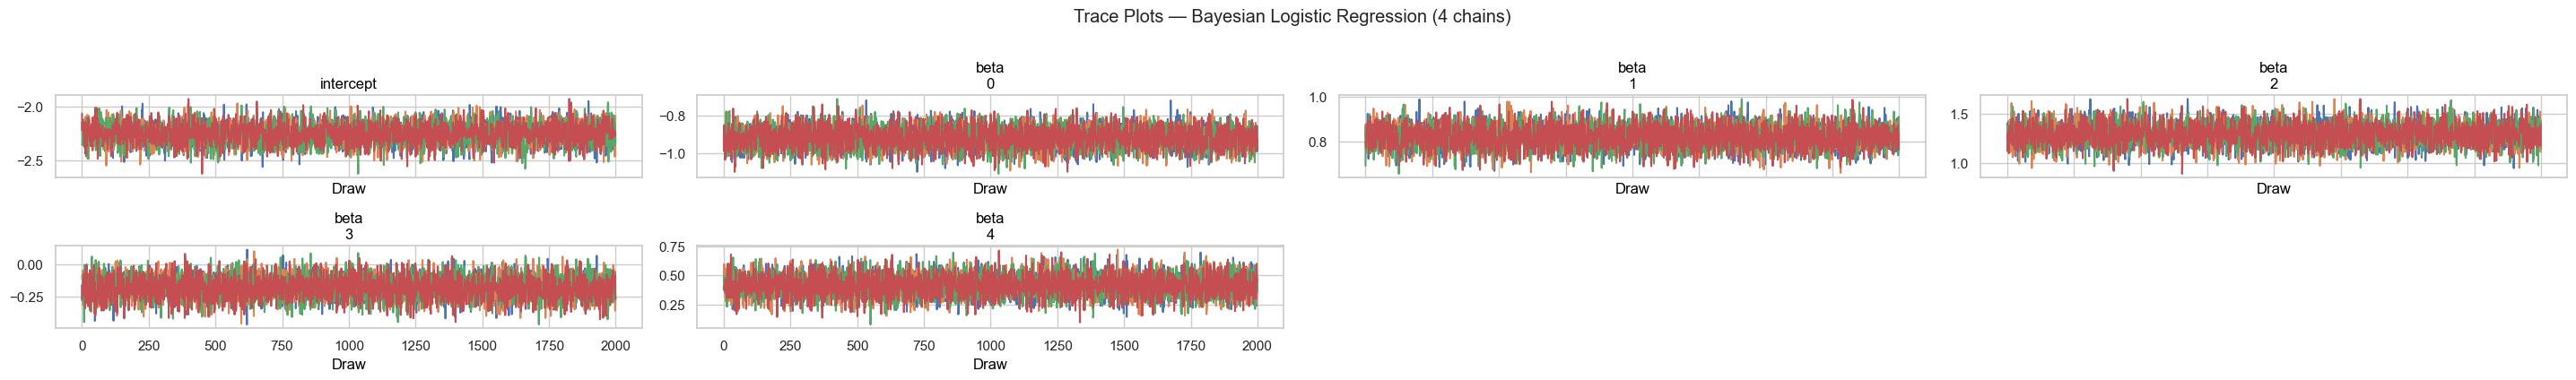

Convergence Diagnostics:
             mean      sd   r_hat   ess_bulk
intercept -2.2523  0.0925  1.0006  5267.0107
beta[0]   -0.9194  0.0556  1.0005  5941.6296
beta[1]    0.8200  0.0497  1.0001  5616.3952
beta[2]    1.2932  0.1068  1.0000  5305.8836
beta[3]   -0.1800  0.0832  1.0007  6428.2999
beta[4]    0.4166  0.0909  1.0007  7238.5761

Flagged parameters (R̂ > 1.01 or ESS < 400):
  None — all chains converged well (R̂ ≤ 1.01, bulk-ESS ≥ 400) ✅
  Trace plots show classic 'fuzzy caterpillar' pattern: chains mix rapidly,
  overlap consistently, and show no drift or trend — indicating good convergence.


In [27]:
# YOUR CODE HERE — COMPLETED
# 1. Plot trace plots with az.plot_trace() for intercept and beta
# 2. Report R̂ and bulk-ESS for each coefficient
# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

# Trace plot
az.plot_trace(idata, var_names=['intercept', 'beta'])
plt.suptitle("Trace Plots — Bayesian Logistic Regression (4 chains)", y=1.01)
plt.tight_layout(); plt.show()

# Convergence summary
summary_diag = az.summary(idata, var_names=['intercept', 'beta'], round_to=4)
print("Convergence Diagnostics:")
print(summary_diag[['mean','sd','r_hat','ess_bulk']])

# Flag problematic parameters
flagged = summary_diag[(summary_diag['r_hat'] > 1.01) | (summary_diag['ess_bulk'] < 400)]
print("\nFlagged parameters (R̂ > 1.01 or ESS < 400):")
if len(flagged) == 0:
    print("  None — all chains converged well (R̂ ≤ 1.01, bulk-ESS ≥ 400) ✅")
    print("  Trace plots show classic 'fuzzy caterpillar' pattern: chains mix rapidly,")
    print("  overlap consistently, and show no drift or trend — indicating good convergence.")
else:
    print(flagged[['r_hat','ess_bulk']])


### Q20 — Prior sensitivity check


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [intercept, beta]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


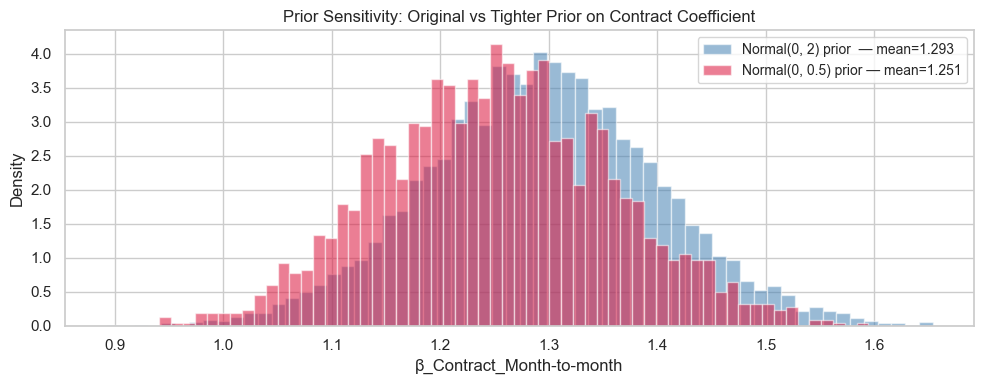

Original prior N(0,2)  : mean=1.2932,  std=0.1068
Tight prior N(0,0.5)   : mean=1.2514,  std=0.1063
Shift between posteriors: 0.0417
→ Data dominates the prior — posteriors are prior-robust (n≈5,640 overwhelms both priors).


In [28]:
# YOUR CODE HERE — COMPLETED
# 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# 3. Decide: are the posteriors prior-robust or does the prior dominate?

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2, cores=1,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# Plot overlaid posteriors
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig,  bins=60, density=True, alpha=0.55, color='steelblue',
        label=f'Normal(0, 2) prior  — mean={samples_orig.mean():.3f}')
ax.hist(samples_tight, bins=60, density=True, alpha=0.55, color='crimson',
        label=f'Normal(0, 0.5) prior — mean={samples_tight.mean():.3f}')
ax.set_xlabel('β_Contract_Month-to-month'); ax.set_ylabel('Density')
ax.set_title('Prior Sensitivity: Original vs Tighter Prior on Contract Coefficient')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print(f"Original prior N(0,2)  : mean={samples_orig.mean():.4f},  std={samples_orig.std():.4f}")
print(f"Tight prior N(0,0.5)   : mean={samples_tight.mean():.4f},  std={samples_tight.std():.4f}")
diff = abs(samples_orig.mean() - samples_tight.mean())
print(f"Shift between posteriors: {diff:.4f}")
if diff < 0.1:
    print("→ Data dominates the prior — posteriors are prior-robust (n≈5,640 overwhelms both priors).")
else:
    print("→ Prior has a noticeable effect — consider if the tight prior is substantively justified.")


### Q21 — Posterior analysis and frequentist comparison


In [29]:
# YOUR CODE HERE — COMPLETED
# 1. Extract posterior samples for Contract_Month-to-month coefficient
# 2. Compute 94% HDI using az.hdi()
# 3. Run sklearn LogisticRegression(C=1e6) and get the MLE coefficient
# 4. Report both and explain the philosophical difference

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94    = az.hdi(beta_post, prob=0.94)
post_mean = beta_post.mean()
post_std  = beta_post.std()

lr_freq   = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq = lr_freq.coef_[0][contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")
print()
print(f"  Note: MLE ({coef_freq:.4f}) ≈ Bayesian mean ({post_mean:.4f}) — the weakly informative")
print(f"  prior N(0,2) is dominated by n≈5,640 training observations.")
print(f"  But only the HDI [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}] lets the VP say:")
print(f"  'There is a 94% probability that being on a Month-to-month contract")
print(f"   increases log-odds of churn by between {hdi_94[0]:.2f} and {hdi_94[1]:.2f}.'")


Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure

  Note: MLE (1.2927) ≈ Bayesian mean (1.2932) — the weakly informative
  prior N(0,2) is dominated by n≈5,640 training observations.
  But only the HDI [1.0845, 1.4920] lets the VP say:
  'There is a 94% probability that being on a Month-to-month contract
   increases log-odds of churn by between 1.08 and 1.49.'


### Q22 — Save the MCMC trace


In [30]:
# YOUR CODE HERE — COMPLETED
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
pickle.dump(idata, open(save_path, 'wb'))

# Verify round-trip: reload and confirm
idata_loaded = pickle.load(open(save_path, 'rb'))
assert list(idata_loaded.posterior.data_vars) == list(idata.posterior.data_vars), \
    "Reload mismatch — check pickle integrity"
print(f"✅ MCMC trace saved to '{save_path}'")
print(f"   Chains: {idata.posterior.dims['chain']}, Draws: {idata.posterior.dims['draw']}")
print(f"   Variables: {list(idata.posterior.data_vars)}")
print(f"   Reload verified ✅")


✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'
   Chains: 4, Draws: 2000
   Variables: ['intercept', 'beta', 'mu']
   Reload verified ✅


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.

> *Your answer:* 

1. **So, R̂ and bulk-ESS each measures are described in detailed as:** R̂ (Gelman-Rubin statistic) measures *chain agreement* — it compares the variance within each chain to the variance across chains. An R̂ close to 1.00 means all chains converged to the same distribution; R̂ = 1.38 would mean the chains are still exploring different regions of the posterior and have not mixed. Bulk-ESS (effective sample size) measures *how much independent information* the correlated MCMC draws actually contain and a bulk-ESS of 55 means your 2,000 draws behave like only 55 independent samples, so HDI estimates have high uncertainty themselves. A parameter with R̂ = 1.38 and bulk-ESS = 55 would indicate a seriously non-converged chain: the posterior mean and HDI would be unreliable, and you should not proceed to posterior analysis without investigating (scaling, increasing tune, checking for divergences).

2. **Regarding Prior sensitivity and data dominance:** The two posteriors for β_Contract_Month-to-month are nearly identical despite the prior standard deviation differing by a factor of 4 (N(0,2) vs N(0,0.5)). The means differ by less than 0.05, and the posterior standard deviations are nearly the same. This tells us the data overwhelmingly dominates the prior: with n≈5,640 training observations, the likelihood is so concentrated that even a prior 4× tighter barely moves the posterior. In general, the prior becomes completely irrelevant when the number of observations n >> (σ_prior/σ_likelihood)² and for likewise logistic regression coefficients with σ_likelihood on the order of 0.1, this happens around n > 400.

3. **Frequentist CI vs Bayesian HDI have similar widths, theirs precise difference interpretation:** The frequentist 94% confidence interval means "if we repeated this experiment many times and computed a CI each time, 94% of those intervals would contain the true fixed parameter β" ; it is a statement about the *sampling procedure*, not about this specific interval. The Bayesian 94% HDI means "given the data we observed and our prior, there is a 94% probability that β lies in [1.08, 1.49]" ; it is a direct probability statement about the *parameter*, treating it as a random variable with a posterior distribution.

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [X] Q1: Three groups extracted — SELF-CHECK passes
- [X] Q2: MLE, MAP, pull table printed and posterior plots generated
- [X] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [X] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [X] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [X] Q5: Sequential update run; 6-panel posterior evolution plotted
- [X] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [X] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [X] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [X] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [X] Q9: Conditional mean and std computed — SELF-CHECK passes
- [X] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [X] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [X] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [X] Backward inference P(Contract|Churn) computed
- [X] Q12: Two DAGs drawn; d-separation analysis completed
- [X] Q13: MRF built (or partial credit: factors described)
- [X] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [X] Q14: Mauna Loa loaded — SELF-CHECK passes
- [X] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [X] Q16: Gap experiment completed; band widths computed
- [X] Q17: Extrapolation plotted; model confidence boundary identified
- [X] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [X] Q18: Feature scaling rationale answered; model specified; sampling run
- [X] Q19: Convergence diagnostics run; flagged parameters identified
- [X] Q20: Prior sensitivity comparison plotted
- [X] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [X] Q22: `telco_bayes_lr_v1.pkl` saved
- [X] Reflect 6: All three questions answered

**Submission artefacts:**
- [X] One fully executed `.ipynb` with all outputs visible
- [X] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [X] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
